In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse


## Load data

In [1]:

m_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/myeloid.h5ad')
l_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad')

NameError: name 'sc' is not defined

In [7]:
import numpy as np

# Subset to Drokhylansky2020
dro_cells = adata.obs['dataset_id'] == 'Smillie2019'
dro_X = adata.X[dro_cells]

# Identify expressed genes (at least one non-zero value)
if hasattr(dro_X, 'tocsc'):  # sparse matrix
    dro_expressed = np.array((dro_X > 0).sum(axis=0)).ravel() > 0
else:  # dense matrix
    dro_expressed = (dro_X > 0).sum(axis=0) > 0

# Get gene names with non-zero expression
drok_var_names_present = set(adata.var_names[dro_expressed])
all_var_names = set(adata.var_names)

# Find missing ones
missing_in_drok = all_var_names - drok_var_names_present

print(f"{len(missing_in_drok)} genes missing (all-zero) in Drokhylansky2020")


5096 genes missing (all-zero) in Drokhylansky2020


In [9]:
missing_with_dot1 = [gene for gene in missing_in_drok if gene.endswith('.1')]

missing_with_dot1

[]

In [8]:
ct_df = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_celltype_metadata.csv')
filtered_df = ct_df.drop_duplicates(subset=['author_cell_type', 'closest_GCA_celltype'])
ct_df = filtered_df.drop_duplicates(subset='author_cell_type', keep='first').reset_index(drop=True)

ct_df.drop(columns=['worksheet','column_4'],inplace=True)

adata.obs = adata.obs.merge(
    ct_df,
    left_on='author_cell_type', right_on='author_cell_type', how='left'
).set_index(adata.obs.index)

adata.obs['closest_GCA_celltype'].value_counts()

closest_GCA_celltype
Fibroblasts                 268391
Enterocytes                 242556
unknown                     175354
Plasma Cells                157955
Epithelial                  119815
                             ...  
Effector/Memory T Cells         26
Pericytes Secretory             23
Granulocytes Eosinophils         1
Neurons Excitory                 1
CD8 Memory                       1
Name: count, Length: 126, dtype: int64

In [9]:
gca_tax = pd.read_csv('../data/gca_celltype_taxonomy.csv')

gca_tax = gca_tax.dropna(subset=['closest_GCA_celltype'])

update_dict = {
    'T Cycling ': 'T Cycling',
    'Cycling T Cells': 'T Cycling',
    'CD4+ T-Cells': 'CD4 T',
    'CD8 GammaDelta': 'T GammaDelta',
    'CD8 MAIT': 'T MAIT',
    'CD8 NK T': 'NKT',
    'CD8+ T-Cells': 'CD8 T',
    'DC Monocyte derived dendritic cell': 'DC Monocyte derived dendritic cell (MO DC)',
    'Germinal Center B Cells (GC)': 'GC B Germinal Center',
    'Treg': 'CD4 Treg',
    'Dendritic Cells': 'Dendritic Cells (DC)',
    'Effector/Memory T Cells': 'CD8 Effector/Memory',
    'Enterochromaffin Cells': 'EEC Enterochromaffin Cells',
    'Germinal Center B Cells': 'GC B Germinal Center',
    'IEL': 'CD8 IEL',
    'ILC NK Cells': 'NK Cells',
    'Interstitial Cells of Cajal (ICC)': 'Fibroblasts Interstitial Cells of Cajal (ICC)',
    'MAIT': 'T MAIT',
    'Mast Cells': 'Granulocytes Mast Cells',
    'Memory B Cells': 'B Memory',
    'Myofibroblasts': 'Fibroblasts Myofibroblasts',
    'Naive B-Cells': 'B Naive',
    'TRM':'CD8 TRM',
    'Tfh': 'CD4 Tfh',
    'Th1': 'CD4 Th1',
    'Th17': 'CD4 Th17',
    'th1': 'CD4 Th1',
    'Secretory Goblet cells Mature ': 'Secretory Goblet cells Mature',
    'Myofibroblasts': 'Fibroblasts Myofibroblasts',
    'CD8 GammaDelta': 'T GammaDelta',
    'CD8 MAIT': 'T MAIT',
    'CD8 NK T': 'NKT',
    'DC pDC': 'pDC',
    'ILC NK Cells': 'NK Cells',
}

adata.obs['closest_GCA_celltype'] = adata.obs['closest_GCA_celltype'].replace(update_dict)


adata.obs = adata.obs.reset_index(names='CellID').merge(gca_tax, 
                                            left_on = 'closest_GCA_celltype', 
                                            right_on= 'closest_GCA_celltype', 
                                            how = 'left').set_index("CellID")



### Add gene symbols back into object

In [13]:

gene_mapping = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/ontology/ensembl_symbol.tsv', 
                           sep='\t', index_col='gene_id')

ensg_to_symbol = gene_mapping['gene_name'].to_dict()

adata.var['gene_symbols'] = adata.var.index.map(ensg_to_symbol)


## Search for celltypes associated with certain signatures

In [11]:
adata.obs['Group_Lineage'] = adata.obs['Lineage'].astype(str)
adata.obs['Group_Differentia'] = adata.obs['Lineage'].astype(str) + '-' + adata.obs['Differentia'].astype(str)
adata.obs['Group_Habitus'] = adata.obs['Lineage'].astype(str) + '-' + adata.obs['Differentia'].astype(str) + '-' + adata.obs['Habitus'].astype(str)
adata.obs['Group_Status'] = adata.obs['Lineage'].astype(str) + '-' + adata.obs['Differentia'].astype(str) + '-' + adata.obs['Habitus'].astype(str) + '-' + adata.obs['Status'].astype(str)
adata.obs['Group_Whim'] = adata.obs['Lineage'].astype(str) + '-' + adata.obs['Differentia'].astype(str) + '-' + adata.obs['Habitus'].astype(str) + '-' + adata.obs['Status'].astype(str) + '-' + adata.obs['Whim'].astype(str)


In [12]:
adata.obs['Group_Lineage'] = pd.Categorical(adata.obs['Group_Lineage'], categories=sorted(adata.obs['Group_Lineage'].unique()), ordered=True)
adata.obs['Group_Differentia'] = pd.Categorical(adata.obs['Group_Differentia'], categories=sorted(adata.obs['Group_Differentia'].unique()), ordered=True)
adata.obs['Group_Habitus'] = pd.Categorical(adata.obs['Group_Habitus'], categories=sorted(adata.obs['Group_Habitus'].unique()), ordered=True)
adata.obs['Group_Status'] = pd.Categorical(adata.obs['Group_Status'], categories=sorted(adata.obs['Group_Status'].unique()), ordered=True)
adata.obs['Group_Whim'] = pd.Categorical(adata.obs['Group_Whim'], categories=sorted(adata.obs['Group_Whim'].unique()), ordered=True)


In [31]:
genes_to_plot = ['AIRE', 'RORC', 'TNFRSF11B', 'NCAM1', 'CD200', 'PRDM16', 'EPCAM', 'PIGR']

In [32]:
# Check if genes exist
[gene for gene in genes_to_plot if gene in adata.var['gene_symbols'].values]

['AIRE', 'RORC', 'TNFRSF11B', 'NCAM1', 'CD200', 'PRDM16', 'EPCAM', 'PIGR']

In [33]:
groupings = ['Group_Lineage', 'Group_Differentia', 'Group_Habitus', 'Group_Status', 'Group_Whim']

fig_sizes = {
    'Group_Lineage': (8, 4),  # Smaller for the lowest resolution
    'Group_Differentia': (10, 6),
    'Group_Habitus': (12, 8),
    'Group_Status': (14, 10),
    'Group_Whim': (16, 12)   # Largest for the highest resolution
}




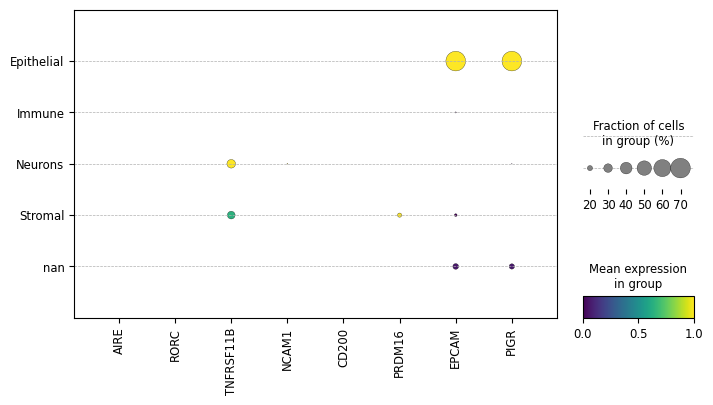

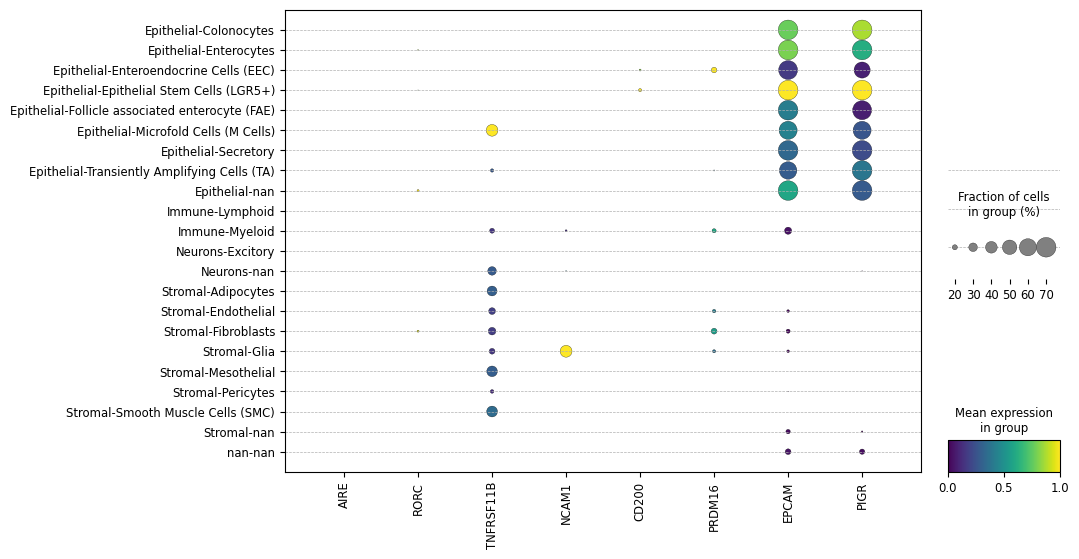

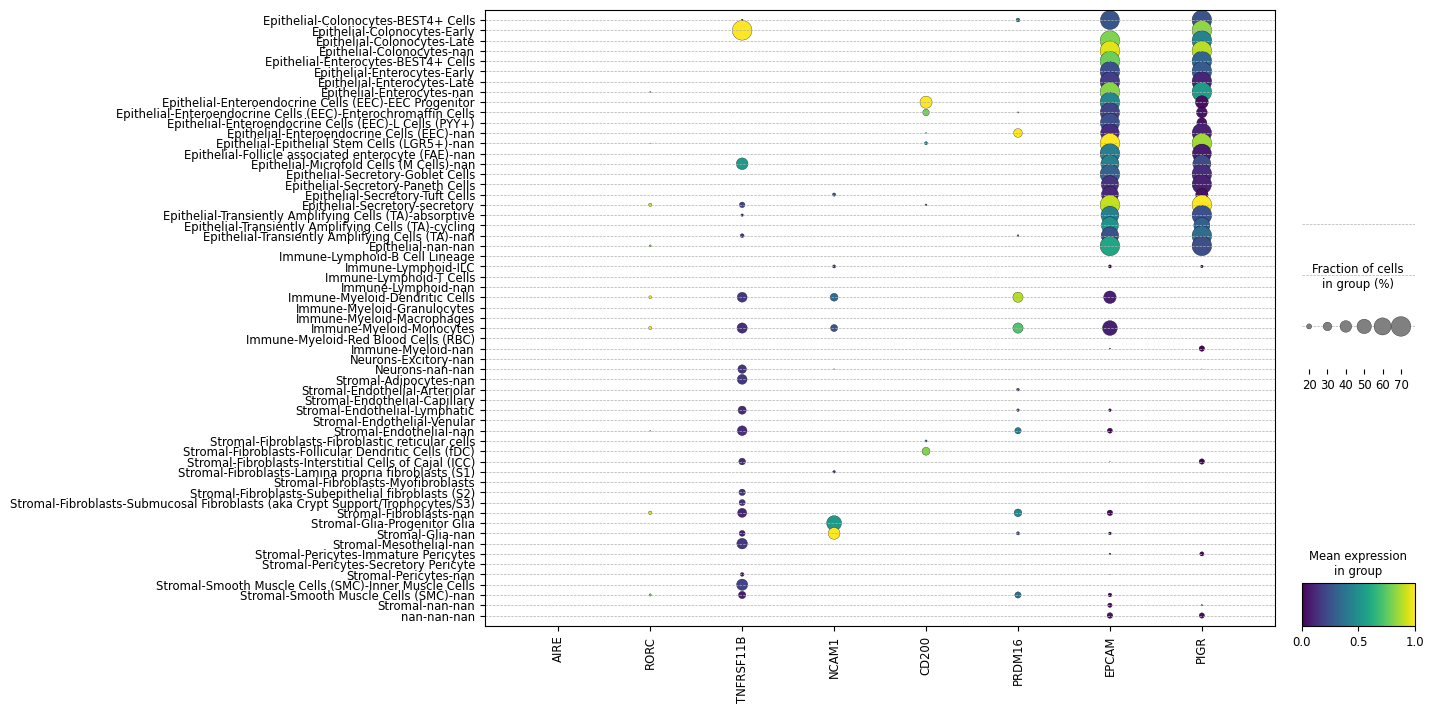

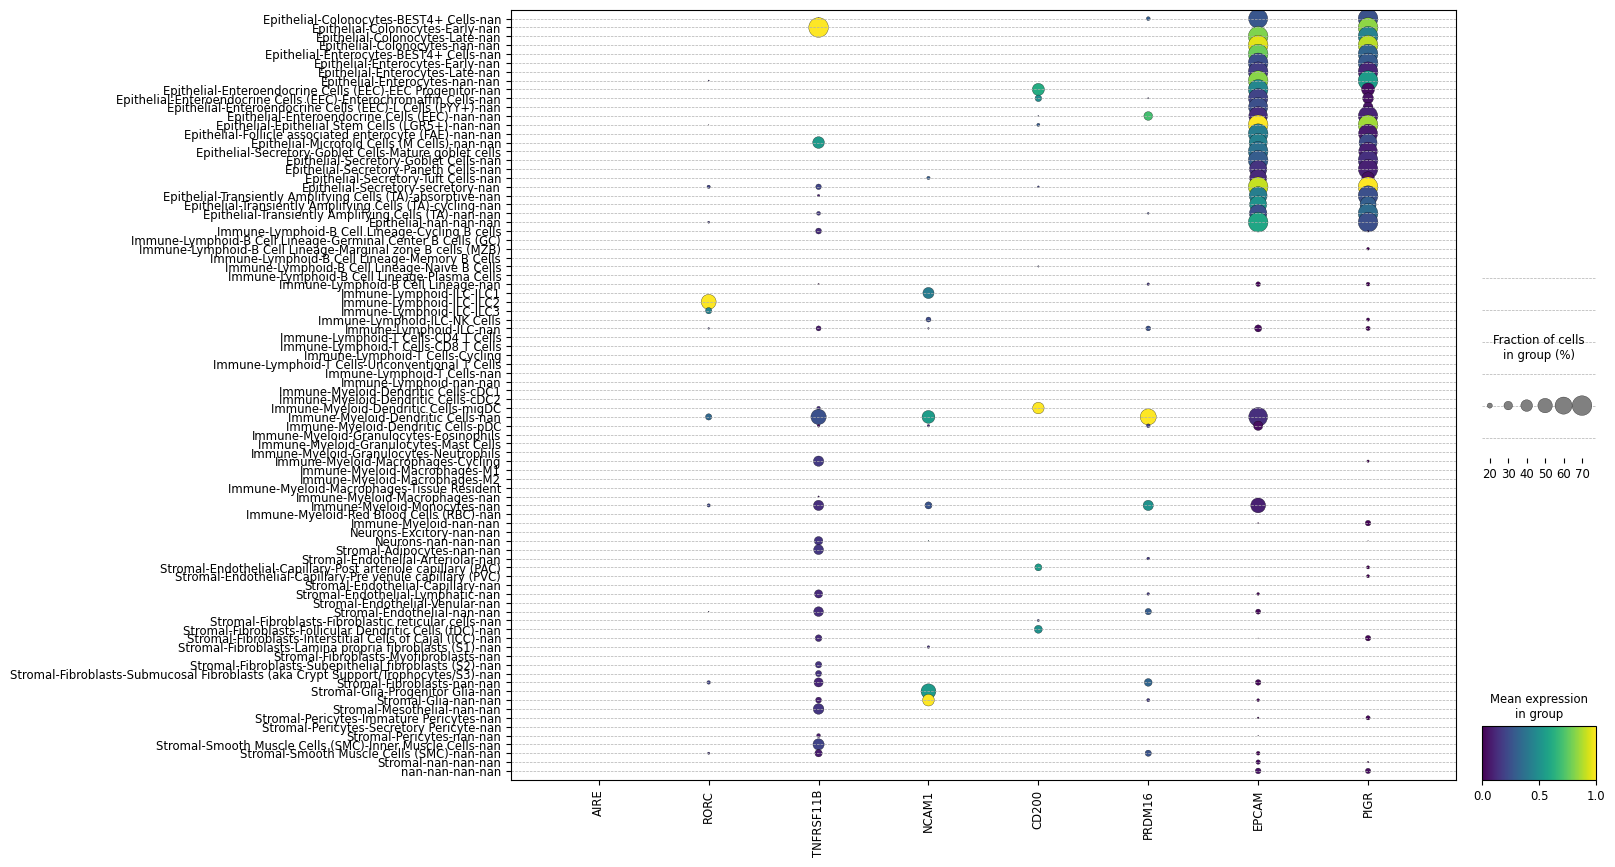

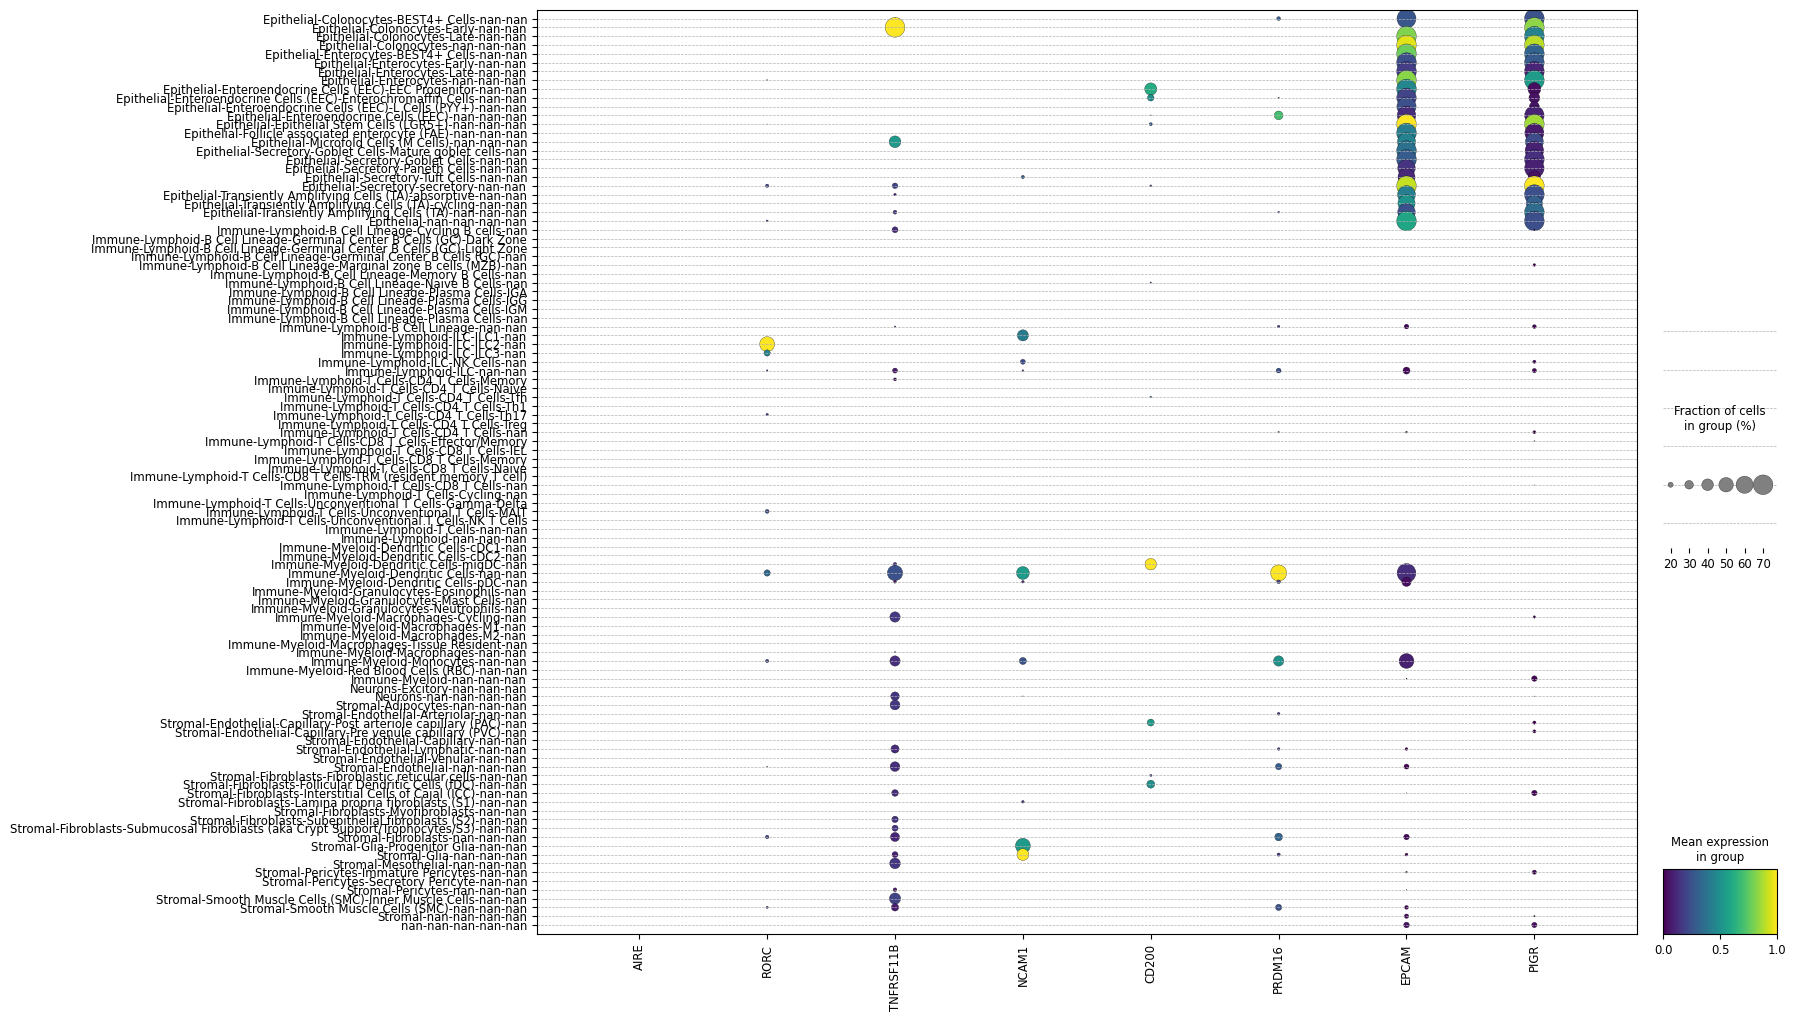

In [34]:
for grouping in fig_sizes:
    axs = sc.pl.dotplot(adata, var_names=genes_to_plot, groupby=grouping, use_raw=False,
                       standard_scale='var', show=False, dot_max=0.7, dot_min=0.1,
                       color_map='viridis', figsize=fig_sizes[grouping], gene_symbols='gene_symbols')
    # Adding horizontal grid lines to each axis for better visualization
    for ax in axs.values():
        ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)
    # Show the plot
    plt.show()

## Find cells which have at least one read for every gene in a list

In [49]:
def add_read_presence_column(adata, valid_genes, column_name='read_presence'):
    """
    Adds a new column to anndata.obs indicating whether each cell has at least one read
    for any of the genes in 'valid_genes'.

    Parameters:
    adata (AnnData): The annotated data matrix.
    valid_genes (list): List of valid gene symbols to check for reads.
    column_name (str): Name of the new column to be added to adata.obs.
    """
    valid_indices = adata.var.index[adata.var['gene_symbols'].isin(valid_genes)]
    if isinstance(adata.X, scipy.sparse.spmatrix):
        presence_matrix = (adata[:, valid_indices].X > 0).toarray()
    else:
        presence_matrix = (adata[:, valid_indices].X > 0)
    adata.obs[column_name] = presence_matrix.all(axis=1)
    print(f"Column '{column_name}' added to adata.obs indicating read presence of all specified genes.")


In [50]:
etac_signature = ['AIRE', 'RORC', 'TNFRSF11B', 'NCAM1', 'PRDM16', 'EPCAM', 'PIGR']

In [51]:
add_read_presence_column(adata, etac_signature, column_name='etac_signature')

Column 'etac_signature' added to adata.obs indicating read presence of all specified genes.


In [52]:
adata.obs.groupby('Lineage')['etac_signature'].sum()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/2773391603.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Lineage')['etac_signature'].sum()


Lineage
Epithelial    0
Immune        0
Neurons       0
Stromal       0
Name: etac_signature, dtype: int64

In [53]:
etac_signature = ['RORC', 'TNFRSF11B', 'NCAM1', 'PRDM16', 'EPCAM', 'PIGR']
add_read_presence_column(adata, etac_signature, column_name='etac_signature')
adata.obs.groupby('Lineage')['etac_signature'].sum()

Column 'etac_signature' added to adata.obs indicating read presence of all specified genes.


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/4088249739.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Lineage')['etac_signature'].sum()


Lineage
Epithelial     10
Immune        267
Neurons         0
Stromal        28
Name: etac_signature, dtype: int64

In [58]:
adata.obs.groupby('radial_tissue_term')['etac_signature'].sum()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/2566192303.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('radial_tissue_term')['etac_signature'].sum()


radial_tissue_term
EPI                  1
EPI_LP               0
EPI_LP_MUSC          6
LP                5966
MNS                  0
Mucosal ILF        148
Peyers patch       100
SUB                322
Submucosal ILF     325
WM                   0
nan                  0
Name: etac_signature, dtype: int64

In [54]:
etac_signature = ['RORC', 'TNFRSF11B', 'NCAM1', 'PRDM16', 'EPCAM']
add_read_presence_column(adata, etac_signature, column_name='etac_signature')
adata.obs.groupby('Lineage')['etac_signature'].sum()

Column 'etac_signature' added to adata.obs indicating read presence of all specified genes.


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/139262325.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Lineage')['etac_signature'].sum()


Lineage
Epithelial     133
Immune        3523
Neurons          0
Stromal        736
Name: etac_signature, dtype: int64

In [59]:
aire_signature = ['AIRE']
add_read_presence_column(adata, aire_signature, column_name='aire_signature')
adata.obs.groupby('Lineage')['aire_signature'].sum()

Column 'aire_signature' added to adata.obs indicating read presence of all specified genes.


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/1387189525.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Lineage')['aire_signature'].sum()


Lineage
Epithelial    372
Immune        492
Neurons         0
Stromal       304
Name: aire_signature, dtype: int64

In [61]:
adata.obs.groupby('Habitus')['aire_signature'].sum()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/2853023123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Habitus')['aire_signature'].sum()


Habitus
Arteriolar                                                     0
B Cell Lineage                                               204
BEST4+ Cells                                                   7
Capillary                                                      1
Dendritic Cells                                               59
EEC Progenitor                                                 0
Early                                                          1
Enterochromaffin Cells                                         4
Fibroblastic reticular cells                                   0
Follicular Dendritic Cells (fDC)                               1
Goblet Cells                                                  22
Granulocytes                                                   5
ILC                                                            8
Immature Pericytes                                             1
Inner Muscle Cells                                             0
Interstitial Cell

In [63]:
adata.obs[(adata.obs["aire_signature"] == True) & (adata.obs['Habitus'] == 'Dendritic Cells')]['dataset_id'].value_counts()


dataset_id
AgaceHelmsley2         16
Kong2023               12
AgaceHelmsley3          7
Luoma2020               4
Elmentaite2020          4
multiome                4
Uzzan2022               3
Zheng2024               3
Huang2019               2
BasuGCARNA              2
AgaceHelmsley1          2
Yu2021                  0
Wang2020                0
Lee2020                 0
Smillie2019             0
Parikh2019              0
Martin2019              0
Maddipatla2023          0
nan                     0
Kinchen2018             0
Krzak2023               0
KarakashevaHelmlsey     0
James2020               0
Jaeger2021              0
He2020                  0
Egozi2023               0
Drokhylansky2020        0
DominguezUnpub          0
Dominguez2022           0
Burclaff2022            0
ArendsHelmsley          0
snRNAseq                0
Name: count, dtype: int64

In [66]:
adata.obs[(adata.obs["aire_signature"] == True) & (adata.obs['Habitus'] == 'Dendritic Cells')]['sample_collection_method'].value_counts()


sample_collection_method
surgical_resection    32
biopsy                27
nan                    0
Name: count, dtype: int64

In [ ]:
adata.obs.groupby('Habitus')['aire_signature'].sum()

In [60]:
adata.obs.groupby('tissue_ontology_term')['aire_signature'].sum()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_51882/436325302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('tissue_ontology_term')['aire_signature'].sum()


tissue_ontology_term
ascending_colon                      150
caecum                                 4
colon                                403
descending_colon                      12
duodenum                              33
gastrointestinal_system_mesentery      7
ileum                                873
jejunum                               84
nan                                   84
rectum                                 4
sigmoid_colon                         28
small_intestine                       20
transverse_colon                      17
vermiform_appendix                     4
Name: aire_signature, dtype: int64

In [85]:
markers = ['AIRE', 'RORC', 'TNFRSF11B', 'NCAM1', 'PRDM16', 'EPCAM', 'TCF4', 'CLEC4A', # etac markers
          'VIL1', 'FABP6',  # possible presentations: enterocytes
          'MUC2', 'TFF3', 'RETNLB', # goblet
          'CHGA', 'NEUROG3', 'SYP', # EEC
          'DEFA5', 'DEFA4', # paneth
          'LGR5', # epith stem
          'DCLK1', 'PLCG2', 'TAS2R38', # tuft
          'ACTA2', 'DES', 'MYH11', # smooth muscle
          'CD3E', 'CD19', 'CD68', # immune
          'FAP', 'PDGFRA'] # fibroblasts

[gene for gene in markers if gene in adata.var['gene_symbols'].values]


['AIRE',
 'RORC',
 'TNFRSF11B',
 'NCAM1',
 'PRDM16',
 'EPCAM',
 'TCF4',
 'CLEC4A',
 'VIL1',
 'FABP6',
 'MUC2',
 'TFF3',
 'RETNLB',
 'CHGA',
 'NEUROG3',
 'SYP',
 'DEFA5',
 'DEFA4',
 'LGR5',
 'DCLK1',
 'PLCG2',
 'TAS2R38',
 'ACTA2',
 'DES',
 'MYH11',
 'CD3E',
 'CD19',
 'CD68',
 'FAP',
 'PDGFRA']

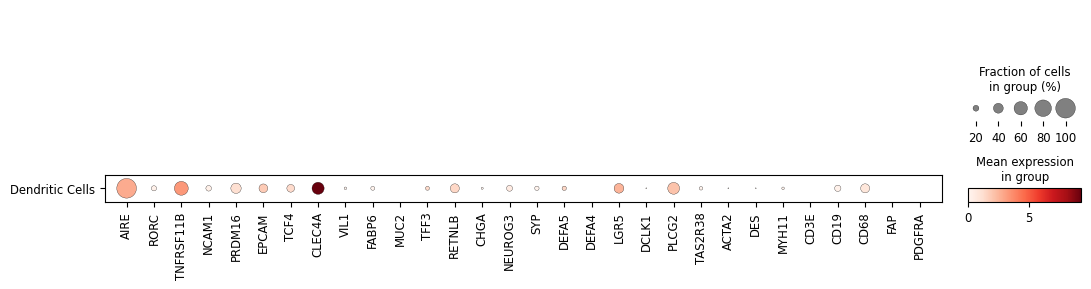

In [90]:
# Plotting expression in AIRE+ cells
sc.pl.dotplot(adata[adata.obs['aire_signature'] & (adata.obs['Habitus'] == 'Dendritic Cells')], var_names=markers, groupby='Habitus',
             gene_symbols='gene_symbols')  # Update the boolean indexing as per your data

In [92]:
tcf_signature = ['TCF4']
add_read_presence_column(adata, tcf_signature, column_name='tcf_presence')
adata.obs['tcf_status'] = adata.obs['tcf_presence'].map({True: 'TCF positive', False: 'TCF negative'})


Column 'tcf_presence' added to adata.obs indicating read presence of all specified genes.


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


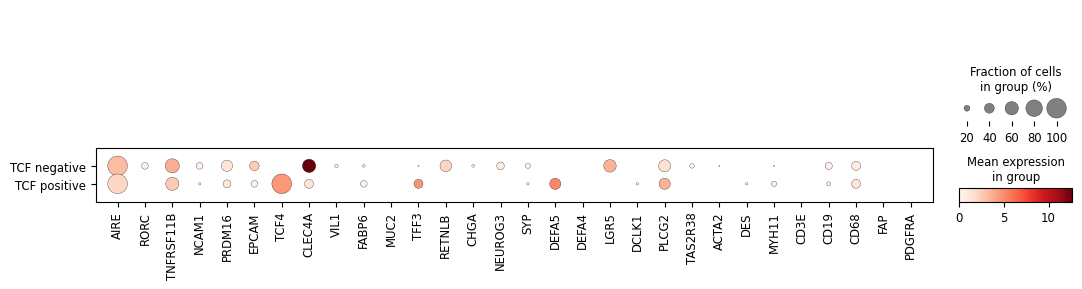

In [97]:
sc.pl.dotplot(adata[adata.obs['aire_signature'] & (adata.obs['Habitus'] == 'Dendritic Cells')], var_names=markers, groupby='tcf_status',
             gene_symbols='gene_symbols')  # Update the boolean indexing as per your data

In [ ]:
sc.pl.dotplot(adata[adata.obs['aire_signature'] & (adata.obs['Habitus'] == 'Dendritic Cells')], var_names=markers, groupby='tcf_status',
             gene_symbols='gene_symbols')  # Update the boolean indexing as per your data

In [99]:
adata.obs[adata.obs['aire_signature'] & (adata.obs['Habitus'] == 'Dendritic Cells')][['tcf_status', 'sampled_site_condition']].value_counts()

tcf_status    sampled_site_condition
TCF negative  healthy                   39
TCF positive  healthy                    9
              adjacent                   5
TCF negative  adjacent                   3
TCF positive  diseased                   3
Name: count, dtype: int64

## Decoupler gene sets for rare cell type

In [35]:
import decoupler as dc


In [ ]:
gene_sets = {'Target_Gene_Set': genes_to_plot}

dc.ora(adata, gene_sets=gene_sets)
